In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotnine as p9

In [17]:
expr_brainspan = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/brainspan_in_AHBA_kwx.csv", index_col=0)
expr_brainspan.shape

(13787, 64)

In [18]:
gene_score = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/05.new_gene_score_list/gene_score_activate_increase_coupling_kwx.csv", header=None)
gene_score.shape

(636, 2)

In [19]:
# n = (gene_score.shape[0] * 0.1)
# top10_genes = gene_score[0].loc[:n].values
all_genes = gene_score[0].astype(str).values
expr_wm = expr_brainspan.loc[expr_brainspan.index.astype(str).isin(all_genes), :]
expr_wm.shape
# expr_wm = expr_brainspan.loc[expr_brainspan.index.isin(top10_genes), :]
# expr_wm.shape

(563, 64)

## All region expression pattern (top10)

In [20]:
stage = ["2-8", "11-18", "18-30", "36-40"]
res = []
gap = 4
for i in range(0, expr_wm.shape[1], gap):
    tmp_wm = expr_wm.iloc[:, i:i+gap]
    region1 = tmp_wm.columns[0].split("|")[0]
    tmp = expr_brainspan.iloc[:, i:i+gap]
    region2 = tmp.columns[0].split("|")[0]

    if region1 != region2:
        print("Inconsistent")
        break
    #if region1 not in ["VFC", "DFC", "MFC"]:
    #    continue

    ## wm genes
    tmp_wm = expr_wm.iloc[:, i:i+gap]
    tmp_wm.columns = pd.Series(tmp_wm.columns).str.split("|", expand=True)[1].values
    tmp_wm = tmp_wm[stage]

    #pca_obj = PCA(n_components=1)
    #components_wm = -pca_obj.fit_transform(tmp_wm.T).ravel()
    #components_wm = components_wm / np.linalg.norm(components_wm) * 2
    mean_wm = tmp_wm.mean(axis=0).values

    ## all genes
    tmp = expr_brainspan.iloc[:, i:i+gap]
    region = tmp.columns[0].split("|")[0]
    tmp.columns = pd.Series(tmp.columns).str.split("|", expand=True)[1].values
    tmp = tmp[stage]

    mean_all = tmp.mean(axis=0).values

    #print(tmp_wm.shape, tmp.shape)
    tmp_df = pd.DataFrame(np.concatenate([mean_wm, mean_all]), columns=["Value"])
    tmp_df["Stage"] = pd.Categorical(stage*2, categories=stage)
    tmp_df["Region"] = np.repeat([region, region], gap)
    tmp_df["Type"] = np.repeat(["WM Mean", "All Mean"], gap)

    res.append(tmp_df)

    #break

In [21]:
res_df = pd.concat(res)
res_df["Stage"] = pd.Categorical(res_df["Stage"], categories=stage)
#res_df

In [22]:
region_order_grouped = [
    # FP
    "VFC", "IPC", "DFC", "OFC",
    "MFC",

    # Primary
    "A1C", "V1C", "M1C", "S1C",

    # Subcortex
    "CBC", "STR", "MD", "AMY",
    "HIP",

    # Temporal
    "STC", "ITC"
]

res_df["Region"] = pd.Categorical(
    res_df["Region"],
    categories=region_order_grouped,
    ordered=True
)

In [32]:
import plotnine as p9
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =========================
# 尺寸换算：278pt * 280pt -> Inch
# =========================
fig_w = 278 / 72
fig_h = 280 / 72

# =========================
# plotnine 主图
# =========================
pca_plot = (
    p9.ggplot(data=res_df)
    + p9.geom_point(
        mapping=p9.aes(x="Stage", y="Value", color="Type", group="Type"),
        size=0.6
    )
    + p9.geom_line(
        mapping=p9.aes(x="Stage", y="Value", color="Type", group="Type"),
        size=0.4
    )
    + p9.scale_color_manual(values={"WM Mean": "#9C4932", "All Mean": "#D48E63"})
    + p9.scale_y_continuous(
        breaks=[1.9, 2.2, 2.5],
        labels=["1.9", "2.2", "2.5"],
        minor_breaks=[]
    )
    + p9.theme_classic()
    + p9.theme(
        figure_size=(fig_w, fig_h),
        axis_title_y=p9.element_text(color="black", size=8, family="Arial"),
        axis_title_x=p9.element_text(
            color="black",
            size=8,
            family="Arial",
            margin={'t': 12}
        ),
        axis_text=p9.element_text(color="black", size=5, family="Arial"),
        strip_text=p9.element_text(size=8, family="Arial", margin={'t': 2, 'b': 2}),
        legend_position="none",
        axis_line=p9.element_line(size=0.3, color="black"),
        axis_ticks=p9.element_line(size=0.3),
        strip_background=p9.element_rect(color="black", size=0.3, fill="none"),
        subplots_adjust={
            "wspace": 0.3,
            "hspace": 0.5,
            "left": 0.12,
            "right": 0.95,
            "top": 0.92,
            "bottom": 0.28
        }
    )
    + p9.facet_wrap("~Region", ncol=4, nrow=4, scales="free_x")
)

fig = pca_plot.draw()

# 手动构造图例
handles = [
    Line2D([0], [0], color="#D48E63", marker='o', linestyle='-', markersize=3, linewidth=0.8),
    Line2D([0], [0], color="#9C4932", marker='o', linestyle='-', markersize=3, linewidth=0.8),
]
labels = ["All Mean", "GCI+ Mean"]

# 图例放在 Stage 下面，完全脱离主图
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.035),
    bbox_transform=fig.transFigure,
    ncol=2,
    frameon=False,
    prop={"family": "Arial", "size": 6},
    handlelength=1.2,
    handletextpad=0.3,
    columnspacing=0.8,
    borderaxespad=0.0
)

# 保存
fig.savefig(
    "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/3.1mean_expr_activate_increase.png",
    dpi=1200
)

plt.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

brainspan_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/brainspan_in_AHBA_kwx.csv"

gene_score_decrease_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/05.new_gene_score_list/gene_score_activate_decrease_coupling_kwx.csv"

out_dir = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/"
os.makedirs(out_dir, exist_ok=True)

stage_order = ["2-8", "11-18", "18-30", "36-40"]

group_order = ["FP", "Primary", "Subcortex", "Temporal"]

region_to_group_map = {
    "VFC": "FP", "IPC": "FP", "DFC": "FP", "OFC": "FP", "MFC": "FP",
    "A1C": "Primary", "V1C": "Primary", "M1C": "Primary", "S1C": "Primary",
    "CBC": "Subcortex", "STR": "Subcortex", "MD": "Subcortex",
    "AMY": "Subcortex", "HIP": "Subcortex",
    "STC": "Temporal", "ITC": "Temporal"
}

SIM_VMIN = -0.2
SIM_VMAX = 0.8

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


expr_brainspan = pd.read_csv(brainspan_path, index_col=0)
print("BrainSpan expression shape:", expr_brainspan.shape)

gene_score_decrease = pd.read_csv(gene_score_decrease_path, header=None)
print("Decrease gene score shape:", gene_score_decrease.shape)

# ============================================================
# 这里已改为：不取 top 10%，直接使用 gene_score 里的全部基因
# ============================================================

all_genes_decrease = gene_score_decrease.iloc[:, 0].dropna().astype(str).unique()

expr_wm_decrease = expr_brainspan.loc[
    expr_brainspan.index.astype(str).isin(all_genes_decrease),
    :
].copy()

print("All decrease genes in gene_score:", len(all_genes_decrease))
print("Matched BrainSpan decrease genes:", expr_wm_decrease.shape)


def make_similarity_cmap():
    return LinearSegmentedColormap.from_list(
        "blue_similarity_cmap",
        ["#CBD9EC", "#355D94"],
        N=256
    )


def zscore_gene_across_regions(stage_region_gene_df):
    X = stage_region_gene_df.copy()
    mu = X.mean(axis=0, skipna=True)
    sd = X.std(axis=0, skipna=True, ddof=0)

    keep = sd.notna() & (sd > 0)
    X = X.loc[:, keep]
    mu = mu.loc[keep]
    sd = sd.loc[keep]

    return (X - mu) / sd


def get_stage_region_gene_matrix(expr_df, stage):
    stage_cols = [c for c in expr_df.columns if c.endswith("|" + stage)]

    if len(stage_cols) == 0:
        raise ValueError(f"没有找到 stage = {stage} 的列。")

    tmp = expr_df.loc[:, stage_cols].copy()
    tmp.columns = [c.split("|")[0] for c in tmp.columns]

    region_gene = tmp.T
    region_gene.index.name = "Region"

    keep_regions = [r for r in region_gene.index if r in region_to_group_map]
    return region_gene.loc[keep_regions]


def compute_region_similarity_by_stage(expr_df, stage, do_gene_zscore=True):
    region_gene = get_stage_region_gene_matrix(expr_df, stage)

    if do_gene_zscore:
        region_gene = zscore_gene_across_regions(region_gene)

    return region_gene.T.corr(method="pearson")


def compute_overall_stage_mean(region_corr):
    vals = region_corr.values[np.triu_indices_from(region_corr.values, k=1)]
    vals = vals[np.isfinite(vals)]
    return np.nan if len(vals) == 0 else float(np.mean(vals))


def compute_group_similarity_matrix(region_corr, group_order):
    out = pd.DataFrame(np.nan, index=group_order, columns=group_order, dtype=float)
    region_group = pd.Series(region_to_group_map)

    for i, g1 in enumerate(group_order):
        regions1 = [r for r in region_corr.index if region_group.get(r, None) == g1]

        for j, g2 in enumerate(group_order):
            if j < i:
                out.loc[g1, g2] = out.loc[g2, g1]
                continue

            regions2 = [r for r in region_corr.columns if region_group.get(r, None) == g2]

            if len(regions1) == 0 or len(regions2) == 0:
                continue

            sub = region_corr.loc[regions1, regions2].copy()

            if g1 == g2:
                vals = sub.values[np.triu_indices_from(sub.values, k=1)]
            else:
                vals = sub.values.ravel()

            vals = vals[np.isfinite(vals)]
            out.loc[g1, g2] = np.nan if len(vals) == 0 else float(np.mean(vals))

    for i, g1 in enumerate(group_order):
        for j, g2 in enumerate(group_order):
            if j < i:
                out.loc[g1, g2] = out.loc[g2, g1]

    return out


def draw_half_similarity_matrix(
    matrix_df,
    save_path,
    title="Expression similarity",
    vmin=SIM_VMIN,
    vmax=SIM_VMAX,
    show_values=True
):
    values = matrix_df.loc[group_order, group_order].values.astype(float)

    cmap = make_similarity_cmap()
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(3.0, 2.7), dpi=1200)
    n = len(group_order)

    for i in range(n):
        for j in range(n):
            if j > i:
                continue

            val = values[i, j]
            if not np.isfinite(val):
                continue

            rect = plt.Rectangle(
                (j - 0.5, i - 0.5),
                1,
                1,
                facecolor=cmap(norm(val)),
                edgecolor="none",
                linewidth=0
            )
            ax.add_patch(rect)

            if show_values:
                text_color = "white" if norm(val) > 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=text_color,
                    fontweight="bold"
                )

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(
        group_order,
        fontsize=7,
        rotation=45,
        ha="right",
        fontweight="bold"
    )
    ax.set_yticklabels(
        group_order,
        fontsize=7,
        fontweight="bold"
    )

    ax.set_title(title, fontsize=9, pad=4, fontweight="bold")
    ax.tick_params(length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=6, width=0.4, length=1.5)
    cbar.outline.set_visible(False)

    for tick in cbar.ax.get_yticklabels():
        tick.set_fontweight("bold")

    plt.subplots_adjust(left=0.22, bottom=0.24, right=0.88, top=0.88)

    fig.savefig(save_path, dpi=1200, facecolor="white", edgecolor="none")
    plt.close(fig)

    print(f"Saved: {save_path}")


def draw_four_stage_group_similarity(stage_group_similarity, save_path):
    cmap = make_similarity_cmap()
    norm = Normalize(vmin=SIM_VMIN, vmax=SIM_VMAX)

    fig, axes = plt.subplots(1, 4, figsize=(7.0, 2.2), dpi=1200)

    for ax, st in zip(axes, stage_order):
        values = stage_group_similarity[st].loc[group_order, group_order].values.astype(float)
        n = len(group_order)

        for i in range(n):
            for j in range(n):
                if j > i:
                    continue

                val = values[i, j]
                if not np.isfinite(val):
                    continue

                rect = plt.Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    facecolor=cmap(norm(val)),
                    edgecolor="none",
                    linewidth=0
                )
                ax.add_patch(rect)

                text_color = "white" if norm(val) > 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=5.5,
                    color=text_color,
                    fontweight="bold"
                )

        ax.set_xlim(-0.5, n - 0.5)
        ax.set_ylim(n - 0.5, -0.5)
        ax.set_aspect("equal")

        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))

        ax.set_xticklabels(
            group_order,
            fontsize=5.5,
            rotation=45,
            ha="right",
            fontweight="bold"
        )

        if ax is axes[0]:
            ax.set_yticklabels(group_order, fontsize=5.5, fontweight="bold")
        else:
            ax.set_yticklabels([])

        ax.set_title(st, fontsize=8, pad=3, fontweight="bold")
        ax.tick_params(length=0)

        for spine in ax.spines.values():
            spine.set_visible(False)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    cbar.ax.tick_params(labelsize=6, width=0.4, length=1.5)
    cbar.outline.set_visible(False)

    for tick in cbar.ax.get_yticklabels():
        tick.set_fontweight("bold")

    plt.subplots_adjust(left=0.08, bottom=0.25, right=0.91, top=0.82, wspace=0.25)

    fig.savefig(save_path, dpi=1200, facecolor="white", edgecolor="none")
    plt.close(fig)

    print(f"Saved: {save_path}")


stage_region_corr_decrease = {}
stage_group_similarity_decrease = {}
stage_mean_summary = []

for st in stage_order:
    corr = compute_region_similarity_by_stage(
        expr_df=expr_wm_decrease,
        stage=st,
        do_gene_zscore=True
    )

    group_mat = compute_group_similarity_matrix(
        region_corr=corr,
        group_order=group_order
    )

    overall_mean = compute_overall_stage_mean(corr)

    stage_region_corr_decrease[st] = corr
    stage_group_similarity_decrease[st] = group_mat

    stage_mean_summary.append(
        {
            "Stage": st,
            "Mean_similarity_all_region_pairs": overall_mean
        }
    )

    print(f"\n========== GCI+ Stage {st}: group expression similarity ==========")
    print(group_mat.round(4).to_string())
    print(f"Overall mean similarity across all region pairs: {overall_mean:.4f}")

    draw_half_similarity_matrix(
        matrix_df=group_mat,
        save_path=os.path.join(
            out_dir,
            f"3.7brainspan_decrease_group_similarity_stage_{st}.png"
        ),
        title=st,
        vmin=SIM_VMIN,
        vmax=SIM_VMAX,
        show_values=True
    )

draw_four_stage_group_similarity(
    stage_group_similarity_decrease,
    os.path.join(
        out_dir,
        "3.7brainspan_decrease_group_similarity_four_stages.png"
    )
)

stage_mean_summary = pd.DataFrame(stage_mean_summary)

print("\n========== Overall mean similarity by stage ==========")
print(stage_mean_summary.round(4).to_string(index=False))

print("\nDone.")
print("只计算了 decrease / GCI-。")
print("使用 gene_score 文件中的全部基因，没有筛选 top 10%。")
print("横纵坐标分组名、阶段名、数值和 colorbar tick 均已加粗。")

BrainSpan expression shape: (13787, 64)
Decrease gene score shape: (927, 2)
All decrease genes in gene_score: 927
Matched BrainSpan decrease genes: (810, 64)

========== GCI+ Stage 2-8: group expression similarity ==========
               FP  Primary  Subcortex  Temporal
FP         0.0348   0.0156    -0.1527    0.1005
Primary    0.0156   0.0231    -0.1601    0.0570
Subcortex -0.1527  -0.1601     0.0203   -0.1591
Temporal   0.1005   0.0570    -0.1591    0.1105
Overall mean similarity across all region pairs: -0.0503
Saved: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/3.7brainspan_decrease_group_similarity_stage_2-8.png

========== GCI+ Stage 11-18: group expression similarity ==========
               FP  Primary  Subcortex  Temporal
FP         0.2157   0.0951    -0.2174    0.1233
Primary    0.0951   0.1694    -0.1703   -0.0496
Subcortex -0.2174  -0.1703    -0.0149   -0.1513
Temporal   0.1233  -0.0496    -0.1513    0.5809
Overall mean similarit

## pairwise stage

In [9]:
def trans2df(df, stage, geneset, region):
    tmp = pd.DataFrame(df, columns=["value"])
    tmp["Stage"] = stage
    tmp["GeneSet"] = geneset
    tmp["Region"] = region
    return tmp

stage = ["2-8", "11-18", "18-30", "36-40"]
label = pd.Series(stage)[:-1].reset_index(drop=True) +"|"+ pd.Series(stage)[1:].reset_index(drop=True)
diff_res = []
ratio_res = []
gap = 4
for i in range(0, expr_wm.shape[1], gap):
    tmp_wm = expr_wm.iloc[:, i:i+gap]
    region1 = tmp_wm.columns[0].split("-")[0]
    tmp = expr_brainspan.iloc[:, i:i+gap]
    region2 = tmp.columns[0].split("-")[0]

    if region1 != region2:
        print("Inconsistent")
        break

    ## wm genes
    tmp_wm = expr_wm.iloc[:, i:i+gap]
    tmp_wm.columns = pd.Series(tmp_wm.columns).str.split("|", expand=True)[1].values
    tmp_wm = tmp_wm[stage]
    mean_wm = tmp_wm.mean(axis=0).values

    diff_wm = mean_wm[1:] - mean_wm[:-1]
    ratio_wm = mean_wm[1:] / mean_wm[:-1]

    ## all genes
    tmp = expr_brainspan.iloc[:, i:i+gap]
    region = tmp.columns[0].split("|")[0]
    tmp.columns = pd.Series(tmp.columns).str.split("|", expand=True)[1].values
    tmp = tmp[stage]
    mean_all = tmp.mean(axis=0).values
    diff_all = mean_all[1:] - mean_all[:-1]
    ratio_all = mean_all[1:] / mean_all[:-1]

    region_flag = region
    diff_res.append(trans2df(diff_wm, stage=label, geneset="wm", region=region_flag))
    diff_res.append(trans2df(diff_all, stage=label, geneset="All", region=region_flag))

    ratio_res.append(trans2df(ratio_wm, stage=label, geneset="wm", region=region_flag))
    ratio_res.append(trans2df(ratio_all, stage=label, geneset="All", region=region_flag))

In [10]:
tmp = pd.concat(diff_res)
tmp2 = tmp.groupby(by=["Stage", "GeneSet"]).mean(numeric_only=True).reset_index()
tmp2["std"] = tmp.groupby(by=["Stage", "GeneSet"]).std(numeric_only=True).values
tmp2["lower"] = tmp2["value"] - tmp2["std"]
tmp2["upper"] = tmp2["value"] + tmp2["std"]
tmp2["Stage"] = pd.Categorical(tmp2["Stage"], categories=label)
tmp2

,Stage,GeneSet,value,std,lower,upper
0,11-18|18-30,All,0.074592,0.046059,0.028532,0.120651
1,11-18|18-30,wm,0.204277,0.111364,0.092912,0.315641
2,18-30|36-40,All,-0.032412,0.041251,-0.073662,0.008839
3,18-30|36-40,wm,-0.110185,0.117196,-0.227381,0.007010
4,2-8|11-18,All,0.078016,0.100574,-0.022558,0.178591
5,2-8|11-18,wm,0.097550,0.152351,-0.054801,0.249901


In [11]:
from scipy.stats import ttest_ind_from_stats
t_test_res = []
for i in range(0, 6, 2):
    stage = tmp2["Stage"][i]
    
    t, p = ttest_ind_from_stats(mean1=tmp2["value"][i+1], std1=tmp2["std"][i+1], nobs1=16,
                                mean2=tmp2["value"][i], std2=tmp2["std"][i], nobs2=16, equal_var=False)
    t_test_res.append([stage, f"T={t:.4}\nP={p:.2e}"])
text_df = pd.DataFrame(t_test_res, columns=["Stage", "label"])
text_df["y"] = 0.8
text_df
text_df["Stage"] = pd.Categorical(text_df["Stage"], categories=label)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


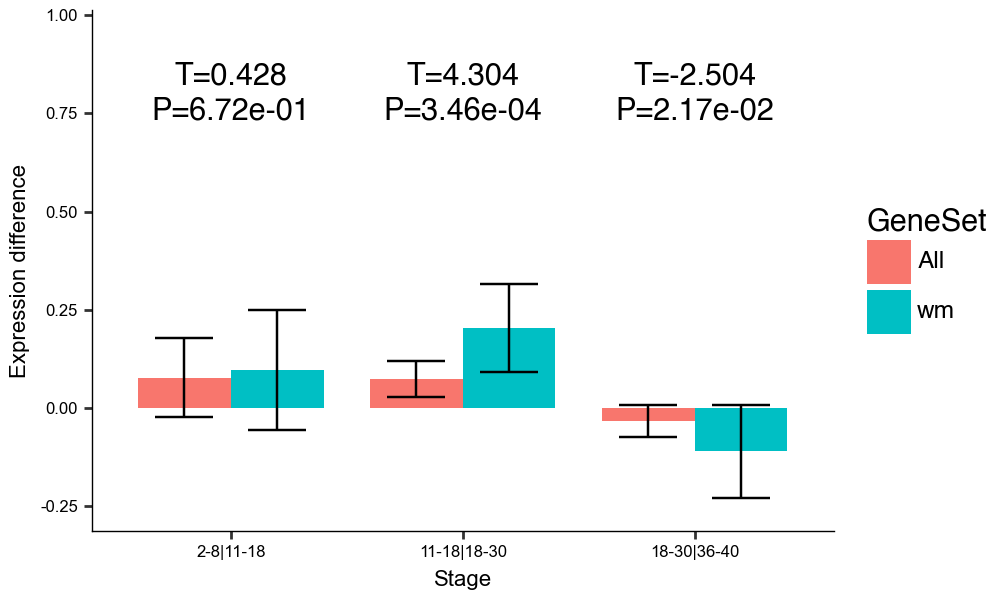

In [12]:
compare_plot = (
    p9.ggplot(mapping=p9.aes(x="Stage", y="value"), data=tmp2)
    #+ p9.geom_bar(mapping=p9.aes(fill="GeneSet"), stat="identity", position="dodge", width=0.7)
    + p9.geom_col(mapping=p9.aes(x="Stage", y="value", fill="GeneSet"), data=tmp2, position="dodge", width=0.8)
    + p9.geom_errorbar(mapping=p9.aes(ymin="lower", ymax="upper", fill="GeneSet"), data=tmp2, position=p9.position_dodge(0.8))
    + p9.geom_text(mapping=p9.aes(x="Stage", y="y", label="label"), data=text_df)
    + p9.theme_classic()
    + p9.ylab("Expression difference")
    + p9.scale_y_continuous(expand = (0.01, 0), limits=(-0.3, 1))
    + p9.theme(figure_size=(5, 3),
               axis_text=p9.element_text(size=6, color="black", family="Arial"),
               axis_text_x=p9.element_text(rotation=0),
               axis_title=p9.element_text(size=8, color="black", family="Arial"),
               subplots_adjust={'wspace': 0.25},
               strip_background=p9.element_rect(size=0.5),
               strip_text=p9.element_text(size=6, family="Arial"),
               axis_line=p9.element_line(size=0.5),
               legend_position="right",
               )
    + p9.guides(fill=p9.guide_legend(order=0))
    #+ p9.facet_wrap("~Gene_sets", nrow=1, ncol=4, scales="free_y")
)
p9.ggsave(compare_plot, "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/all_stage_diff_activate_decrease_kwx.pdf", verbose=False)
compare_plot

## pairwise stage (each region)

expr_brainspan: (13787, 64)
genes in gene_score file: 927
genes in expr (intersection): 810
long_df: (38880, 4)
Saved long: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/WM_only_region_adjStageDiff_activate_decrease_kwx.long.csv
Saved summary: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/WM_only_region_adjStageDiff_activate_decrease_kwx.summary.csv
Saved plot: /Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/WM_only_region_adjStageDiff_activate_decrease_kwx.pdf


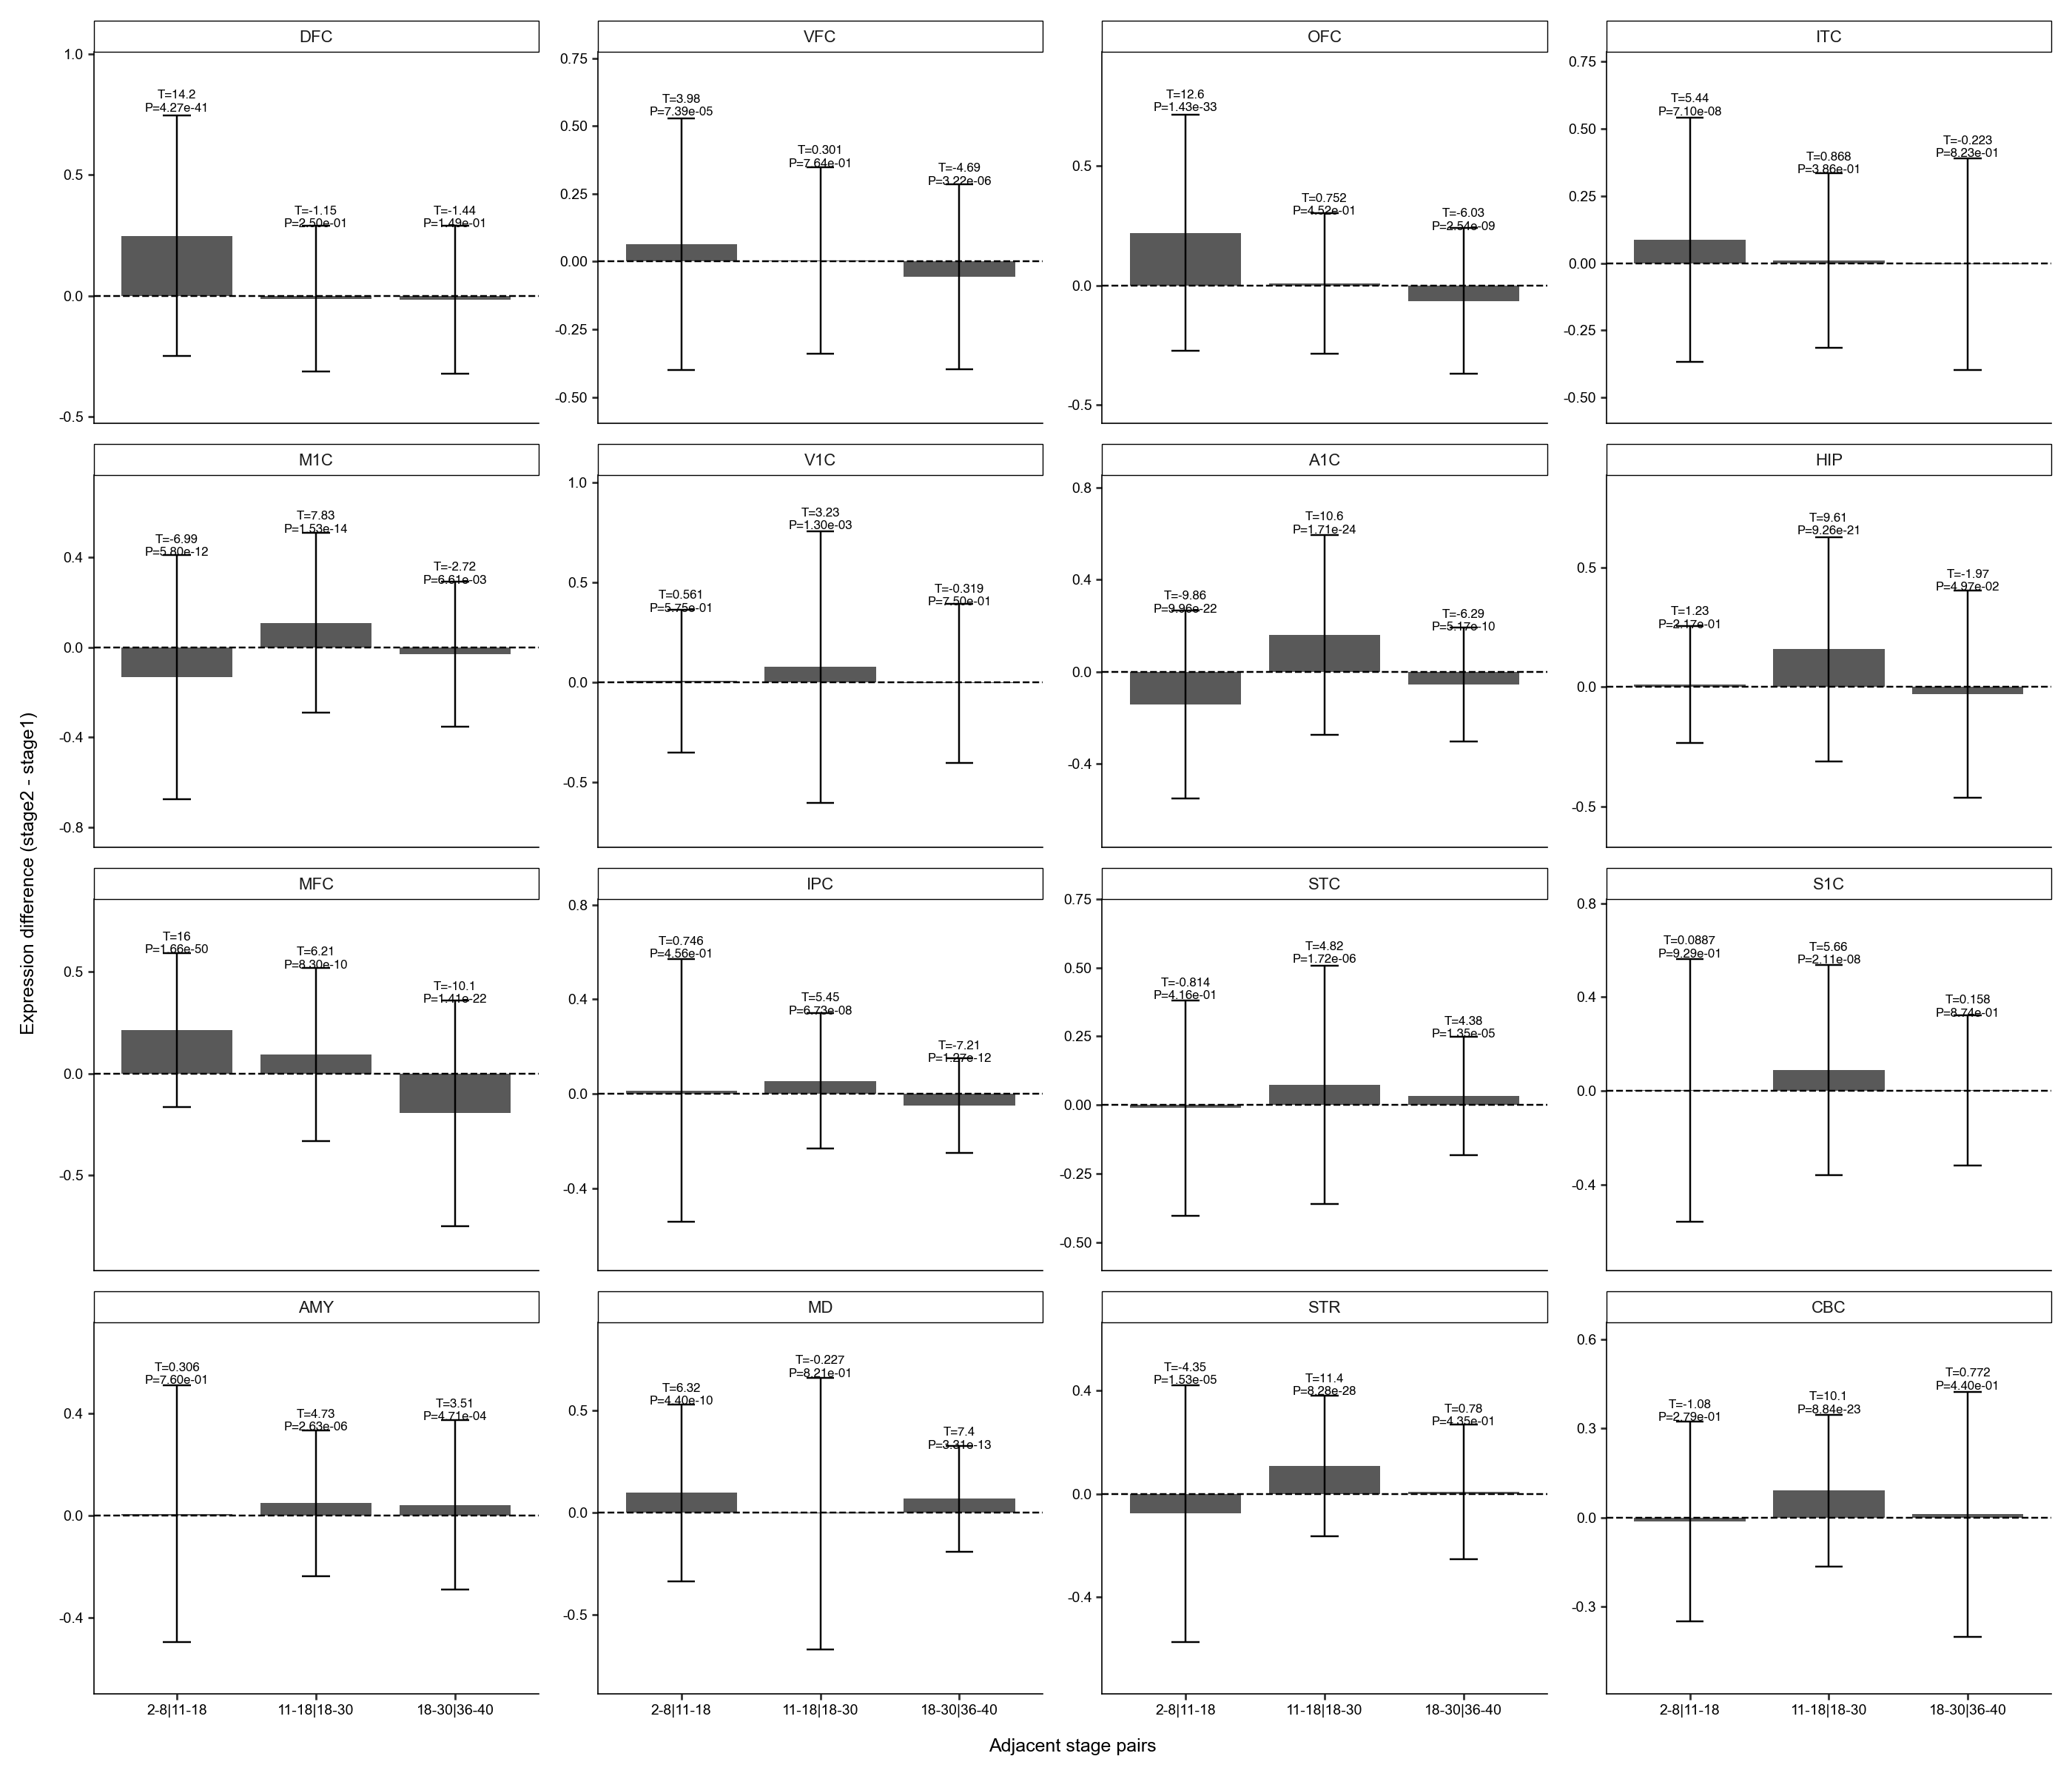

In [13]:
import numpy as np
import pandas as pd
import plotnine as p9
from scipy.stats import ttest_1samp

# =========================
# 0) 文件路径（按你的）
# =========================
expr_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/brainspan_in_AHBA_kwx.csv"
gene_score_path = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/05.new_gene_score_list/gene_score_activate_decrease_coupling_kwx.csv"

out_pdf = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/WM_only_region_adjStageDiff_activate_decrease_kwx.pdf"
out_csv_long = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/WM_only_region_adjStageDiff_activate_decrease_kwx.long.csv"
out_csv_summary = "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/09.brainspan/WM_only_region_adjStageDiff_activate_decrease_kwx.summary.csv"

# =========================
# 1) 读 brainspan 表达矩阵
#    行：gene_symbol
#    列：REGION|STAGE
# =========================
expr_brainspan = pd.read_csv(expr_path, index_col=0)
print("expr_brainspan:", expr_brainspan.shape)

# =========================
# 2) 读 gene_score：不再筛选 top10%，直接用文件中的全部基因
#    兼容无表头/有表头
# =========================
gs_raw = pd.read_csv(gene_score_path, header=None)

# 如果第一格像是表头字符串，则重读为 header=0
if isinstance(gs_raw.iloc[0, 0], str) and gs_raw.iloc[0, 0].strip().lower() in {"gene_symbol", "genesymbol", "gene"}:
    gene_score = pd.read_csv(gene_score_path, header=0)
    if "gene_symbol" in gene_score.columns:
        all_genes_from_score = gene_score["gene_symbol"].astype(str).values
    else:
        all_genes_from_score = gene_score.iloc[:, 0].astype(str).values
else:
    # 无表头：默认第一列就是基因名
    all_genes_from_score = gs_raw.iloc[:, 0].astype(str).values

print("genes in gene_score file:", len(all_genes_from_score))

# 只保留 brainspan 里存在的基因（交集）
genes_in_expr = expr_brainspan.index.intersection(all_genes_from_score)
print("genes in expr (intersection):", len(genes_in_expr))

# =========================
# 3) 解析列名 REGION|STAGE
# =========================
def parse_region_stage(col: str):
    parts = str(col).split("|")
    if len(parts) != 2:
        return None, None
    return parts[0], parts[1]

col_info = pd.DataFrame([parse_region_stage(c) for c in expr_brainspan.columns],
                        columns=["Region", "Stage"])
col_info["col"] = expr_brainspan.columns.values

# 你的四个 stage 顺序
stages = ["2-8", "11-18", "18-30", "36-40"]
pairs = list(zip(stages[:-1], stages[1:]))   # (2-8,11-18), (11-18,18-30), (18-30,36-40)
pair_labels = [f"{a}|{b}" for a, b in pairs]

# 你常用的 region 顺序（可改）
region_order = [
    'DFC', 'VFC', 'OFC', 'ITC',
    'M1C', 'V1C', 'A1C', 'HIP',
    'MFC', 'IPC', 'STC', 'S1C',
    'AMY', 'MD',  'STR', 'CBC',
]

# =========================
# 4) 取某个 region 的表达矩阵：行=gene，列=4个stage
# =========================
def get_region_stage_matrix(expr_df: pd.DataFrame, region: str, stages: list):
    cols_r = col_info[(col_info["Region"] == region) & (col_info["Stage"].isin(stages))]
    if cols_r.shape[0] == 0:
        return None

    df_r = expr_df.loc[:, cols_r["col"].values].copy()
    df_r.columns = cols_r["Stage"].values

    # 补齐缺失 stage，保证列顺序固定
    for s in stages:
        if s not in df_r.columns:
            df_r[s] = np.nan
    df_r = df_r[stages]
    return df_r

# =========================
# 5) 生成 long 表：每个 gene 的 diff（相邻stage）
# =========================
long_rows = []
for region in region_order:
    df_all = get_region_stage_matrix(expr_brainspan, region, stages)
    if df_all is None:
        continue

    # 只保留 gene_score 文件中出现、且在 brainspan 表达矩阵里存在的基因
    df_use = df_all.loc[df_all.index.intersection(genes_in_expr)].copy()
    if df_use.shape[0] == 0:
        continue

    for (s1, s2), lab in zip(pairs, pair_labels):
        diff = (df_use[s2] - df_use[s1]).astype(float)
        tmp = pd.DataFrame({
            "Region": region,
            "StagePair": lab,
            "gene": df_use.index.astype(str).values,
            "diff": diff.values
        })
        long_rows.append(tmp)

long_df = pd.concat(long_rows, axis=0, ignore_index=True)
long_df["diff"] = pd.to_numeric(long_df["diff"], errors="coerce")
long_df = long_df.dropna(subset=["diff"]).reset_index(drop=True)

long_df["Region"] = pd.Categorical(long_df["Region"], categories=region_order, ordered=True)
long_df["StagePair"] = pd.Categorical(long_df["StagePair"], categories=pair_labels, ordered=True)

print("long_df:", long_df.shape)
long_df.to_csv(out_csv_long, index=False)
print("Saved long:", out_csv_long)

# =========================
# 6) summary：每个 region × stagepair 的 mean/std/n
# =========================
summary_df = (
    long_df
    .groupby(["Region", "StagePair"], observed=True)["diff"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "value", "count": "n"})
)
summary_df["lower"] = summary_df["value"] - summary_df["std"]
summary_df["upper"] = summary_df["value"] + summary_df["std"]

summary_df.to_csv(out_csv_summary, index=False)
print("Saved summary:", out_csv_summary)

# =========================
# 7) one-sample t-test：每个 region × stagepair，检验 diff 的均值是否为 0
# =========================
tt_rows = []
for region in region_order:
    for sp in pair_labels:
        vals = long_df[(long_df["Region"] == region) & (long_df["StagePair"] == sp)]["diff"].values

        if len(vals) < 3:
            t, p = np.nan, np.nan
        else:
            t, p = ttest_1samp(vals, popmean=0.0, nan_policy="omit")

        # 文本 y：用当前柱子的 upper + margin
        tmp_upper = summary_df[(summary_df["Region"] == region) & (summary_df["StagePair"] == sp)]["upper"]
        y = float(tmp_upper.max()) if tmp_upper.shape[0] else 0.0
        y = y + 0.05 * (abs(y) + 1e-6) + 0.02

        label = f"T={t:.3g}\nP={p:.2e}" if np.isfinite(p) else "T=NA\nP=NA"

        tt_rows.append({"Region": region, "StagePair": sp, "label": label, "y": y})

text_df = pd.DataFrame(tt_rows)
text_df["Region"] = pd.Categorical(text_df["Region"], categories=region_order, ordered=True)
text_df["StagePair"] = pd.Categorical(text_df["StagePair"], categories=pair_labels, ordered=True)

# =========================
# 8) 画图：柱子=mean diff，误差=±std，文本=t/p）
# =========================
plot = (
    p9.ggplot(summary_df, p9.aes(x="StagePair", y="value"))
    + p9.geom_col(width=0.8)
    + p9.geom_errorbar(p9.aes(ymin="lower", ymax="upper"), width=0.2)
    + p9.geom_hline(yintercept=0, linetype="dashed")
    + p9.geom_text(
        p9.aes(x="StagePair", y="y", label="label"),
        data=text_df,
        inherit_aes=False,
        size=6
    )
    + p9.facet_wrap("~Region", ncol=4, scales="free_y")
    + p9.scale_y_continuous(expand=(0.05, 0.15))
    + p9.theme_classic()
    + p9.ylab("Expression difference (stage2 - stage1)")
    + p9.xlab("Adjacent stage pairs")
    + p9.theme(
        figure_size=(14, 12),
        axis_text=p9.element_text(size=7, color="black", family="Arial"),
        axis_text_x=p9.element_text(rotation=0),
        axis_title=p9.element_text(size=9, color="black", family="Arial"),
        strip_background=p9.element_rect(size=0.5),
        strip_text=p9.element_text(size=8, family="Arial"),
        axis_line=p9.element_line(size=0.6),
        legend_position="none",
    )
)

p9.ggsave(plot, out_pdf, verbose=False)
print("Saved plot:", out_pdf)

plot